In [1]:
pip install gymnasium numpy matplotlib

   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/952.1 kB ? eta -:--:--
   ---------------------------------------- 952.1/952.1 kB 2.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# PART 1 — Multi-Armed Bandit Implementation

## Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

## Custom Multi-Armed Bandit Environment

In [3]:
class BanditEnv(gym.Env):

    def __init__(self, k=10):
        super().__init__()

        self.k = k
        self.action_space = spaces.Discrete(k)
        self.observation_space = spaces.Discrete(1)

        self.q_true = None
        self.best_action = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # True reward values for each arm
        self.q_true = np.random.normal(0, 1, self.k)

        # Best possible action
        self.best_action = np.argmax(self.q_true)

        return 0, {}

    def step(self, action):

        reward = np.random.normal(self.q_true[action], 1)

        terminated = False
        truncated = False

        return 0, reward, terminated, truncated, {}

## ε-Greedy Agent

In [4]:
class EpsilonGreedyAgent:

    def __init__(self, k, epsilon):
        self.k = k
        self.epsilon = epsilon

        self.Q = np.zeros(k)
        self.N = np.zeros(k)

    def select_action(self):

        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)

        return np.argmax(self.Q)

    def update(self, action, reward):

        self.N[action] += 1

        self.Q[action] += (reward - self.Q[action]) / self.N[action]

## UCB Agent

In [5]:
class UCBAgent:

    def __init__(self, k, c):
        self.k = k
        self.c = c

        self.Q = np.zeros(k)
        self.N = np.zeros(k)
        self.t = 0

    def select_action(self):

        self.t += 1

        # Ensure each action is tried at least once
        for a in range(self.k):
            if self.N[a] == 0:
                return a

        ucb = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)

        return np.argmax(ucb)

    def update(self, action, reward):

        self.N[action] += 1

        self.Q[action] += (reward - self.Q[action]) / self.N[action]

## Experiment Function

In [6]:
def run_experiment(agent_class, param, steps=2000, runs=1000):

    rewards = np.zeros((runs, steps))
    optimal_actions = np.zeros((runs, steps))

    for r in range(runs):

        env = BanditEnv()
        env.reset()

        agent = agent_class(10, param)

        for t in range(steps):

            action = agent.select_action()

            _, reward, _, _, _ = env.step(action)

            agent.update(action, reward)

            rewards[r, t] = reward

            if action == env.best_action:
                optimal_actions[r, t] = 1

    avg_reward = rewards.mean(axis=0)
    optimal_percent = optimal_actions.mean(axis=0)

    return avg_reward, optimal_percent

## Run Experiments

### ε-Greedy (ε ∈ {0.01, 0.1, 0.2})

In [7]:
epsilons = [0.01, 0.1, 0.2]

eps_results = {}

for e in epsilons:
    reward, optimal = run_experiment(EpsilonGreedyAgent, e)
    eps_results[e] = (reward, optimal)

### UCB (different confidence levels)

In [8]:
ucb_values = [1, 2, 5]

ucb_results = {}

for c in ucb_values:
    reward, optimal = run_experiment(UCBAgent, c)
    ucb_results[c] = (reward, optimal)

## Plot Average Reward

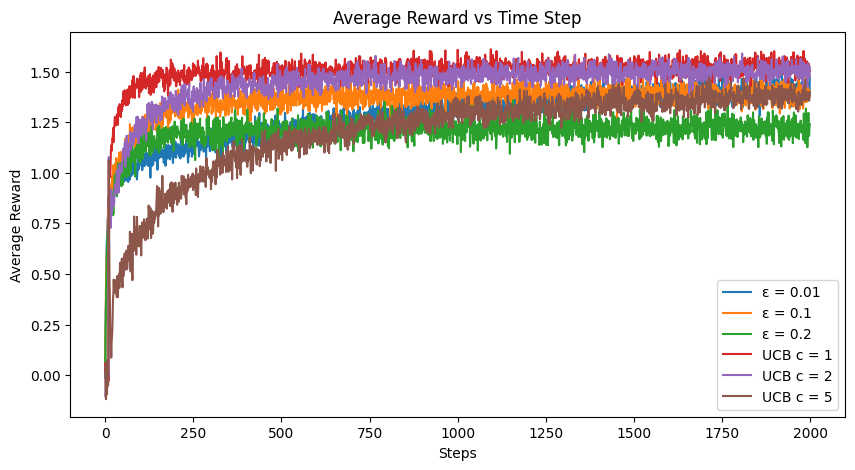

In [9]:
plt.figure(figsize=(10,5))

for e in epsilons:
    plt.plot(eps_results[e][0], label=f"ε = {e}")

for c in ucb_values:
    plt.plot(ucb_results[c][0], label=f"UCB c = {c}")

plt.title("Average Reward vs Time Step")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.show()

## Plot Optimal Action Percentage

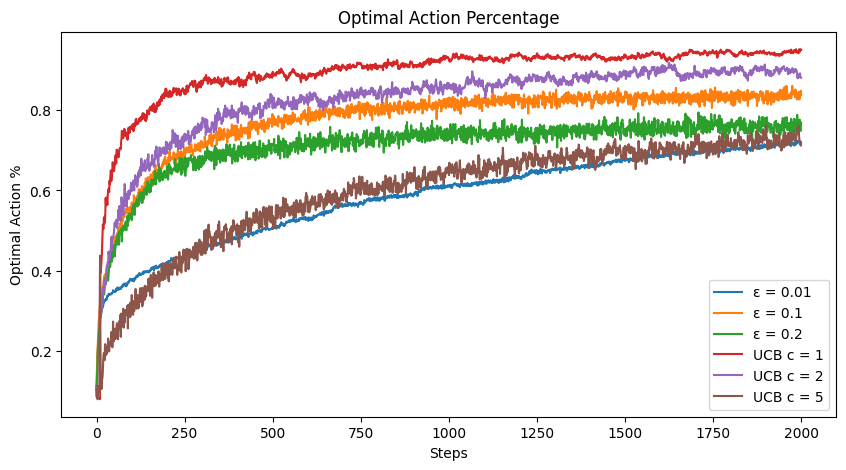

In [10]:
plt.figure(figsize=(10,5))

for e in epsilons:
    plt.plot(eps_results[e][1], label=f"ε = {e}")

for c in ucb_values:
    plt.plot(ucb_results[c][1], label=f"UCB c = {c}")

plt.title("Optimal Action Percentage")
plt.xlabel("Steps")
plt.ylabel("Optimal Action %")
plt.legend()
plt.show()

# PART 2 — Gymnasium Environment Exploration

## FrozenLake Environment

In [11]:
env = gym.make("FrozenLake-v1")

print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Discrete(16)
Action Space: Discrete(4)


## Taxi Environment

In [12]:
env = gym.make("Taxi-v3")

print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Discrete(500)
Action Space: Discrete(6)


## Random Policy Agent

In [13]:
def random_agent(env, episodes=500):

    total_rewards = []

    for _ in range(episodes):

        state, _ = env.reset()

        done = False
        reward_sum = 0

        while not done:

            action = env.action_space.sample()

            state, reward, terminated, truncated, _ = env.step(action)

            reward_sum += reward

            done = terminated or truncated

        total_rewards.append(reward_sum)

    return np.mean(total_rewards)

## Evaluate Random Agent

In [14]:
env = gym.make("FrozenLake-v1")

print("Random Agent Average Reward:", random_agent(env))

Random Agent Average Reward: 0.014


In [15]:
env = gym.make("Taxi-v3")

print("Random Agent Average Reward:", random_agent(env))

Random Agent Average Reward: -770.566
